# Olympic Performance Analyzer

## 1. Load Data

In [316]:
import pandas as pd

df = pd.read_csv("../data/raw/athlete_events.csv")
regions = pd.read_csv("../data/raw/noc_regions.csv")

df.shape

(271116, 15)

## 2. Preview Raw Data

In [317]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 3. Create Working Copy

In [318]:
clean_df = df.copy()
clean_df.shape

(271116, 15)

## 4. Filter Medal Winners

In [319]:
filtered_df = clean_df[clean_df['Medal'].notnull()]
filtered_df.shape

(39783, 15)

## 5. Deduplicate Team Event Medals

The raw dataset is athlete level so team medals can appear multiple times because every athlete on a team receives a row and to count actual medals accurately, I deduplicate by Year, Sport, Event, NOC and Medal.

In [320]:
dedup_df = filtered_df.drop_duplicates(subset=["Year", "Sport", "Event", "NOC", "Medal"]).copy()
dedup_df.shape


(18905, 15)

## 6. Create Medal Points Feature

In [321]:
medal_map = {
  "Gold": 3, 
  "Silver": 2, 
  "Bronze": 1
}

dedup_df["Medal_Points"] = dedup_df["Medal"].map(medal_map)
dedup_df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal_Points
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,3
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,1
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,1
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,1
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,1


## 7. Top Countries by Total Medals

In [322]:
top_country_medals = dedup_df.groupby('NOC').size().sort_values(ascending=False)
top_country_medals.head(10)

NOC
USA    2823
URS    1197
GER    1004
GBR     919
FRA     879
ITA     722
SWE     657
CHN     595
RUS     584
GDR     519
dtype: int64

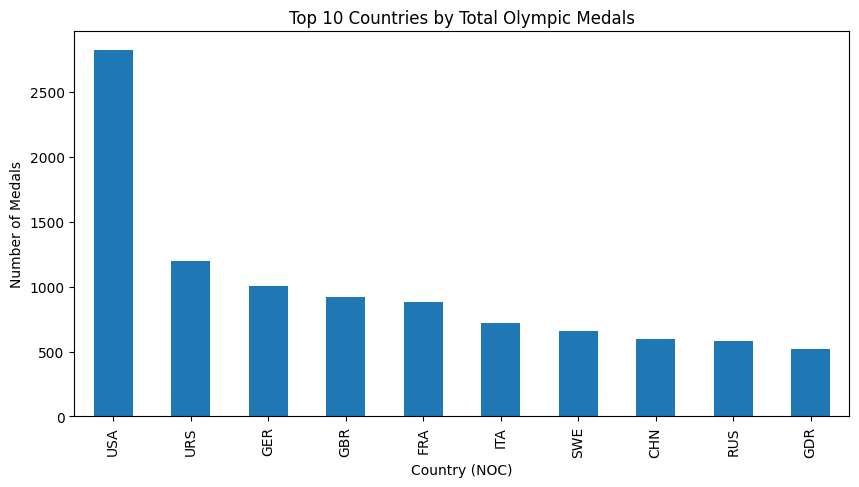

In [323]:
import matplotlib.pyplot as plt

top_country_medals.head(10).plot(kind='bar', title='Top 10 Countries by Total Olympic Medals', xlabel = 'Country (NOC)', ylabel = 'Number of Medals', figsize=(10,5))
plt.savefig("../outputs/charts/top_country_medals.png", bbox_inches='tight')
plt.show()

## 8. Top Countries by Medal Points

In [324]:
top_country_medal_points = dedup_df.groupby('NOC')['Medal_Points'].sum().sort_values(ascending=False)
top_country_medal_points.head(10)

NOC
USA    5986
URS    2512
GER    1987
GBR    1817
FRA    1693
ITA    1459
SWE    1272
CHN    1257
RUS    1171
GDR    1068
Name: Medal_Points, dtype: int64

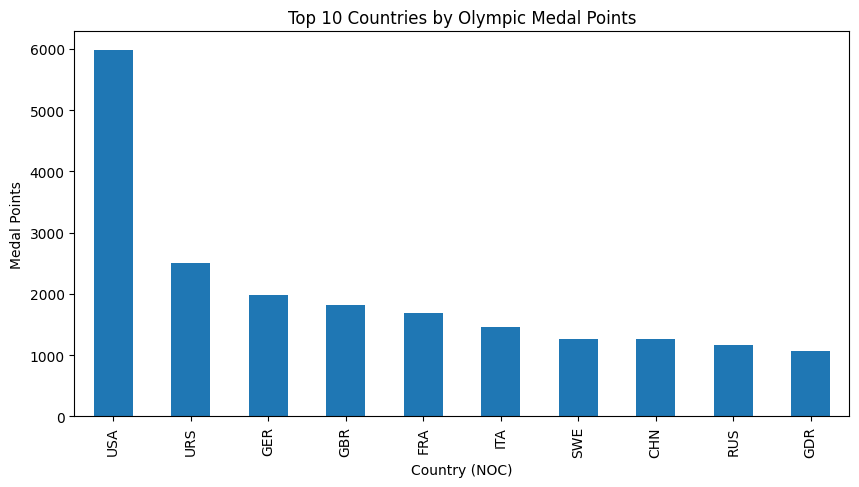

In [325]:
top_country_medal_points.head(10).plot(kind='bar', title='Top 10 Countries by Olympic Medal Points', xlabel='Country (NOC)', ylabel='Medal Points', figsize=(10,5))
plt.savefig("../outputs/charts/top_country_medal_points.png", bbox_inches='tight')
plt.show()

## 9. Top Sports by Medals

In [326]:
top_sports_medals = dedup_df.groupby('Sport').size().sort_values(ascending=False)
top_sports_medals.head(10)

Sport
Athletics     3003
Swimming      1685
Wrestling     1296
Gymnastics     974
Boxing         944
Shooting       853
Rowing         783
Cycling        740
Canoeing       679
Fencing        655
dtype: int64

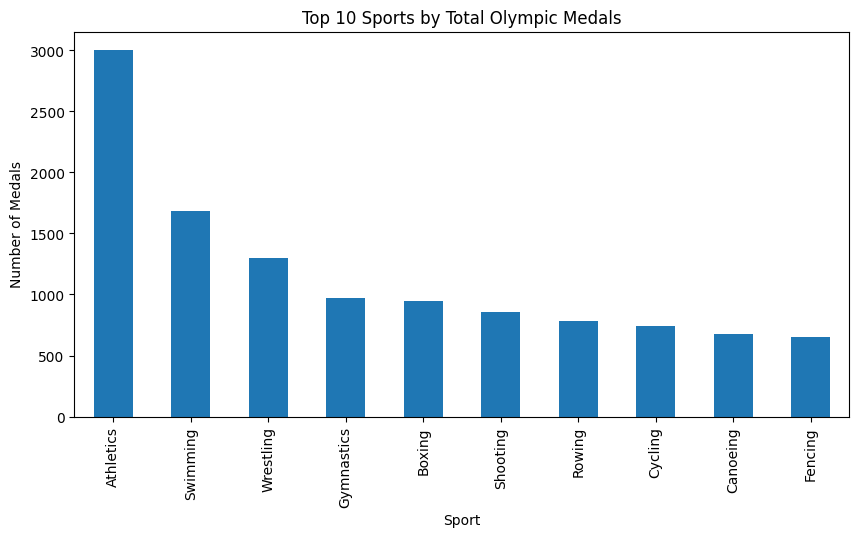

In [327]:
top_sports_medals.head(10).plot(kind='bar', title='Top 10 Sports by Total Olympic Medals', ylabel='Number of Medals', figsize=(10,5))
plt.savefig("../outputs/charts/top_sports_medals.png", bbox_inches='tight')
plt.show()

## Key Findings

- The USA has the most Olympic medals by far compared to the other countries 
- Countries like the Soviet Union (URS) and East Germany (GDR) appear a lot which shows how older countries affect the data. 
- The rankings do not change as much when using medal points instead of total medals so the top countries usually win both more medals and more gold medals. 
- Athletics and Swimming have the highest number of medals which is expected because they include many different events. 

## 10. Dominance Analysis by Sport

In [328]:
sport_totals = top_sports_medals.reset_index(name='Total_Sport_Medals')
country_sport_medals = dedup_df.groupby(['Sport', 'NOC'])['Medal'].size().sort_values(ascending=False).reset_index(name='Medal_Count')
dominance_df = pd.merge(sport_totals, country_sport_medals, on='Sport')
dominance_df['Dominance_Score'] = dominance_df['Medal_Count'] / dominance_df['Total_Sport_Medals']
dominance_df.sort_values("Dominance_Score", ascending=False).head(10)

,Sport,Total_Sport_Medals,NOC,Medal_Count,Dominance_Score
1448,Basque Pelota,1,ESP,1,1.000000
1420,Croquet,7,FRA,7,1.000000
1446,Roque,3,USA,3,1.000000
1433,Racquets,6,GBR,6,1.000000
1447,Aeronautics,1,SUI,1,1.000000
1437,Motorboating,3,GBR,2,0.666667
1441,Jeu De Paume,3,GBR,2,0.666667
1439,Cricket,3,GBR,2,0.666667
1434,Lacrosse,5,CAN,3,0.600000
1396,Golf,18,USA,10,0.555556


## Note on Dominance Scores

Some sports show very high dominance scores (close to 100%), but this is usually because they have very few total medals. For example, sports such as Basque Pelota or Aeronautics only appear a small number of times in Olympic history. This results in a dominance score of 100% for countries that win all the medals in those sports which may not show long-term dominance. Due to this, dominance scores are more meaningful for sports with a larger number of total medals.

## 11. Medal Trends Over Time

In [329]:
medal_trends = dedup_df.groupby('Year')['Medal'].size().reset_index(name='Number of Medals').sort_values(by='Year', ascending=True)
medal_trends.head()

,Year,Number of Medals
0,1896,120
1,1900,291
2,1904,279
3,1906,224
4,1908,320


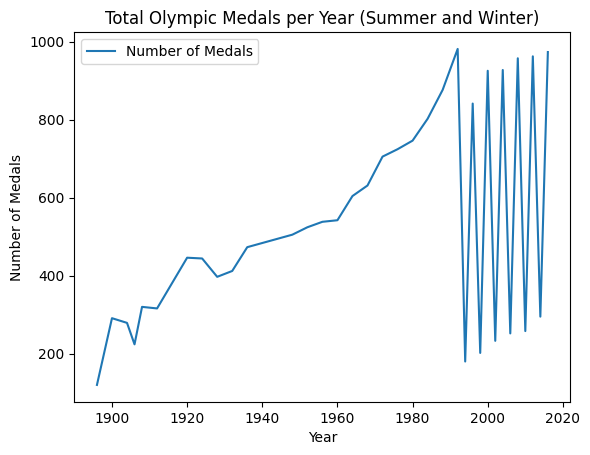

In [330]:
medal_trends.plot(kind='line', x='Year', y='Number of Medals', title='Total Olympic Medals per Year (Summer and Winter)', xlabel='Year', ylabel='Number of Medals')
plt.savefig("../outputs/charts/medal_trends.png", bbox_inches='tight')
plt.show()

This graph includes both Summer and Winter Olympics which is why there are changes in the number of medals across the years.

## 12. Medal Trends by Country Over Time

In [331]:
medal_trends_by_country = dedup_df.groupby(['Year', 'NOC'])['Medal'].size().reset_index(name='Number of Medals').sort_values(by='Year',ascending= True)
medal_trends_by_country.head()

,Year,NOC,Number of Medals
0,1896,AUS,3
1,1896,AUT,5
5,1896,GER,14
6,1896,GRE,44
7,1896,HUN,6


## 13. Focus on Top Countries

In [332]:
top_countries = ['USA', 'URS', 'GER', 'GBR', 'FRA']
filtered_country_trends = medal_trends_by_country[medal_trends_by_country['NOC'].isin(top_countries)]
filtered_country_trends.head()

,Year,NOC,Number of Medals
5,1896,GER,14
9,1896,USA,19
3,1896,FRA,11
4,1896,GBR,9
21,1900,GER,8


## 14. Country Performance Trends

In [333]:
wide_filtered_country_trends = filtered_country_trends.pivot(index='Year', columns='NOC', values='Number of Medals')
wide_filtered_country_trends.head(35)

NOC,FRA,GBR,GER,URS,USA
Year,,,,,
1896,11.0,9.0,14.0,NaN,19.0
1900,102.0,42.0,8.0,NaN,54.0
1904,2.0,2.0,16.0,NaN,230.0
1906,41.0,25.0,14.0,NaN,23.0
1908,19.0,143.0,13.0,NaN,46.0
1912,15.0,41.0,26.0,NaN,63.0
1920,42.0,43.0,NaN,NaN,95.0
1924,43.0,40.0,NaN,NaN,103.0
1928,26.0,23.0,40.0,NaN,62.0


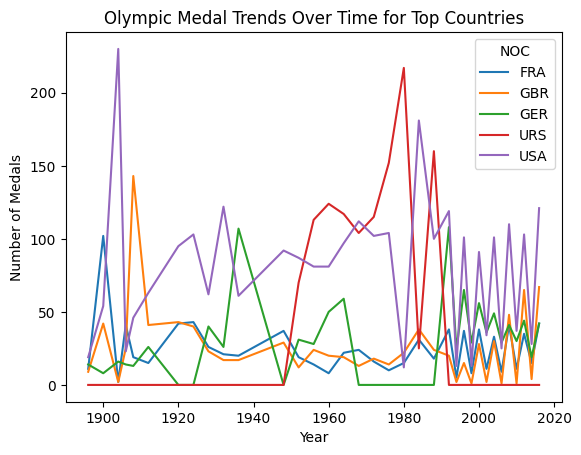

In [334]:
wide_filtered_country_trends = wide_filtered_country_trends.fillna(0)
wide_filtered_country_trends.plot(kind='line', xlabel='Year', ylabel='Number of Medals', title='Olympic Medal Trends Over Time for Top Countries')
plt.savefig("../outputs/charts/wide_filtered_country_trends.png", bbox_inches='tight')
plt.show()

The Soviet Union (URS) only appears during part of the timeline, while the USA consistently appears across most Olympic years. This shows how historical country changes affect the long-term comparisons. 

## 15. Key Findings from Trends Analysis

- The total number of Olympic medals increases over time as more events are added to the Olympics. 
- The USA has maintained a consistent and strong performance across most of the Olympic years. 
- Countries such as the Soviet Union (URS) only appear during certain years which affects the long-term analysis. 
- The variation in medal counts in the later years is due to including both Summer and Winter Olympics which have different numbers of events. 

## 16. Medal Distribution by Sport and Country

In [335]:
sport_country_medals = dedup_df.groupby(['Sport', 'NOC'])['Medal'].size().sort_values(ascending= False).reset_index(name='Sport_Medal_Count')
sport_country_medals.head(10)

,Sport,NOC,Sport_Medal_Count
0,Athletics,USA,816
1,Swimming,USA,550
2,Athletics,GBR,212
3,Athletics,URS,193
4,Swimming,AUS,193
5,Gymnastics,URS,179
6,Diving,USA,135
7,Wrestling,USA,128
8,Fencing,ITA,127
9,Fencing,FRA,123


## 17. Country Specialization by Sport

In [336]:
total_medals = dedup_df.groupby('NOC')['Medal'].size().sort_values(ascending=True).reset_index(name='Total_Country_Medals')
country_sport_medals = pd.merge(sport_country_medals, total_medals, on='NOC')
country_sport_medals['Specialization_Score'] = country_sport_medals['Sport_Medal_Count'] / country_sport_medals['Total_Country_Medals']
country_sport_medals.head()

,Sport,NOC,Sport_Medal_Count,Total_Country_Medals,Specialization_Score
0,Athletics,USA,816,2823,0.289054
1,Swimming,USA,550,2823,0.194828
2,Athletics,GBR,212,919,0.230686
3,Athletics,URS,193,1197,0.161236
4,Swimming,AUS,193,519,0.371869


## 18. Identify Each Country's Strongest Sport

In [337]:
sorted_country_sports = country_sport_medals.sort_values(by=['NOC', 'Specialization_Score'], ascending=[True, False])
country_top_sport = sorted_country_sports.groupby('NOC').first().reset_index()
country_top_sport.head(10)

,NOC,Sport,Sport_Medal_Count,Total_Country_Medals,Specialization_Score
0,AFG,Taekwondo,2,2,1.000000
1,AHO,Sailing,1,1,1.000000
2,ALG,Athletics,9,17,0.529412
3,ANZ,Swimming,8,12,0.666667
4,ARG,Boxing,24,74,0.324324
5,ARM,Wrestling,8,16,0.500000
6,AUS,Swimming,193,519,0.371869
7,AUT,Alpine Skiing,114,326,0.349693
8,AZE,Wrestling,23,44,0.522727
9,BAH,Athletics,12,14,0.857143


## 19. Rank Countries by Sport Specialization

In order to make the specialization score more meaningful, I filtered out the countries with fewer than 10 medals. Countries with only 1 or 2 medals can easily have a specialization score of 1.0 because all of their medals may come from one sport. By using a minimum medal amount, the ranking will focus on countries with enough medal history for the specialization score to be more useful. 

In [338]:
specialized_countries = country_top_sport[country_top_sport['Total_Country_Medals'] >= 10].sort_values(by='Specialization_Score', ascending=False)
specialized_countries.head(20)

,NOC,Sport,Sport_Medal_Count,Total_Country_Medals,Specialization_Score
39,ETH,Athletics,53,53,1.000000
68,JAM,Athletics,75,76,0.986842
72,KEN,Athletics,93,100,0.930000
9,BAH,Athletics,12,14,0.857143
83,MAR,Athletics,19,23,0.826087
100,PAK,Hockey,8,10,0.800000
132,TTO,Athletics,15,19,0.789474
84,MAS,Badminton,8,11,0.727273
3,ANZ,Swimming,8,12,0.666667
134,TUR,Wrestling,63,95,0.663158


## 20. Key Findings for Specialization Analysis

From this analysis, I found that some countries heavily relied on one main sport for their Olympic medals. After filtering to countries with at least 10 medals, the results became more useful because countries with only 1 or 2 medals were not taking over the rankings. 

One thing that stood out is that the Athletics sport appears a lot near the top. Countries such as Ethiopia, Jamaica, Kenya, Bahamas, Morocco, Trinidad and Tobago, Nigeria and Algeria all had Athletics as their strongest sport. This makes sense because many of these countries are known for their strong performances in track and field events. 

There were also other sports that showed up as a country's strongest area such as Wrestling, Badminton, Boxing, Hockey, Swimming and Canoeing. This shows that countries can have very different Olympic strengths depending on the sports where they have had the most success.

Overall, this section helped to show that the total medals do not explain everything. A country might not have one of the highest medal totals overall, but it can still be very strong in one specific sport. 

### Main Points

- Filtering to countries with at least 10 medals made the results less misleading. 
- Athletics was one of the most common top sports for highly specialized countries. 
- Some countries have most of their Olympic success concentrated in one sport. 
- Specialization score gives a different view of Olympic performance than just looking at total medals. 

## 21. Save Processed Data

In [339]:
dedup_df.to_csv("../data/processed/olympics_cleaned.csv", index=False)
medal_trends.to_csv("../data/processed/medal_trends.csv", index=False)
country_top_sport.to_csv("../data/processed/country_top_sport.csv", index=False)
specialized_countries.to_csv("../data/processed/specialized_countries.csv", index=False)
top_country_medals.to_csv("../data/processed/top_country_medals.csv")
top_country_medal_points.to_csv("../data/processed/top_country_medal_points.csv")